# BTC Price Forecasting — Full Report
## Regression & Classification Models Across Daily / Hourly / Weekly Frequencies

**Pipeline:**
1. Load frozen CSV datasets (daily / hourly / weekly).
2. Train regression models → predict exact next-period BTC price.
3. Train classification models → predict direction (Up / Down).
4. Compare via SMAPE/MASE (regression) and ROC-AUC/F1 (classification).

In [1]:
import sys, os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

sys.path.insert(0, '.')
from ml_models import (
    LinearForecaster, StackingForecaster, ARIMAForecaster,
    compute_metrics,
    LinearClassifier, StackingClassifierModel,
    compute_clf_metrics,
)

plt.rcParams['figure.figsize'] = (14, 5)
plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


## 1. Configuration & Data Loading

In [ ]:
# ── Data source ───────────────────────────────────────────────────────────────
# 'csv'  → load pre-built datasets from local CSV files (fast, offline)
# 'api'  → collect fresh data via get_data.py  (requires FRED_API_KEY, ~5-15 min)
DATA_SOURCE = 'api'

# ── CSV paths (used when DATA_SOURCE == 'csv') ────────────────────────────────
DAILY_PATH   = 'new_day_df.csv'
HOURLY_PATH  = 'new_hour_df.csv'
WEEKLY_PATH  = 'new_week_df.csv'
FIVEMIN_PATH = 'new_5min_df.csv'   # generated by build_minute_dataset(); only ~60 days window

# ── Collection settings (used when DATA_SOURCE == 'api') ─────────────────────
import os
# FRED_API_KEY = os.getenv('FRED_API_KEY', '')   # or paste key directly: '...'
FRED_API_KEY = '6a6f2223ac49bf0fbb489f73a509bb18'
START_DATE   = '2018-01-01'
END_DATE     = None     # None → today
SAVE_CSV     = True     # persist freshly collected data back to the CSV paths above

# ── Model / experiment config ─────────────────────────────────────────────────
TARGET = 'BTC'

# ── Hyperparameter search & experiment tracking ───────────────────────────────
OPTUNA_TRIALS = 50                          # Optuna trials per model
WANDB_PROJECT = os.getenv('WANDB_PROJECT')  # None → W&B logging disabled (no auth required)

FREQ_CONFIGS = {
    'Daily':  {'test_size': 260,  'top_features': 30, 'ma_window': 7,  'skip_arima': False},
    'Hourly': {'test_size': 720,  'top_features': 25, 'ma_window': 24, 'skip_arima': False},
    'Weekly': {'test_size': 52,   'top_features': 20, 'ma_window': 4,  'skip_arima': False},
    # 5-min: Yahoo Finance provides only last ~60 days; no FRED/FNG/Supply features
    # skip_arima=True: fitting ARIMA on 15k+ rows is too slow
    '5min':   {'test_size': 2016, 'top_features': 20, 'ma_window': 12, 'skip_arima': True},
}

print(f'DATA_SOURCE = {DATA_SOURCE!r}')
print(f'TARGET      = {TARGET!r}')
print(f'OPTUNA_TRIALS = {OPTUNA_TRIALS}, WANDB_PROJECT = {WANDB_PROJECT!r}')
print(f'Frequencies : {list(FREQ_CONFIGS.keys())}')

DATA_SOURCE = 'api'
TARGET      = 'BTC'
OPTUNA_TRIALS = 50, WANDB_PROJECT = None
Frequencies : ['Daily', 'Hourly', 'Weekly', '5min']


In [ ]:
datasets = {}

if DATA_SOURCE == 'csv':
    _paths = {
        'Daily':  DAILY_PATH,
        'Hourly': HOURLY_PATH,
        'Weekly': WEEKLY_PATH,
        '5min':   FIVEMIN_PATH,
    }
    for freq in FREQ_CONFIGS:
        path = _paths[freq]
        try:
            df = pd.read_csv(path, index_col=0, parse_dates=True)
            datasets[freq] = df
            print(f'{freq:8s}: {df.shape[0]:6d} rows × {df.shape[1]:3d} cols  |  '
                  f'BTC [{df[TARGET].min():.0f} – {df[TARGET].max():.0f}]  |  '
                  f'NaN: {df.isnull().sum().sum()}')
        except FileNotFoundError:
            print(f'{freq:8s}: CSV not found ({path!r}) — skipping. '
                  'Set DATA_SOURCE="api" to build it.')

elif DATA_SOURCE == 'api':
    from get_data import DataMaker
    if not FRED_API_KEY:
        raise ValueError(
            "FRED_API_KEY is not set.\n"
            "Export it:  export FRED_API_KEY=your_key\n"
            "or paste it directly into FRED_API_KEY above."
        )
    print('Initialising DataMaker — data collection may take 5–15 minutes...\n')
    _dm = DataMaker(start_date=START_DATE, end_date=END_DATE, fred_api_key=FRED_API_KEY)

    _builders = {
        'Daily':  _dm.build_daily_dataset,
        'Hourly': _dm.build_hourly_dataset,
        'Weekly': _dm.build_weekly_dataset,
        '5min':   _dm.build_minute_dataset,
    }
    for freq in FREQ_CONFIGS:
        print(f'  Building {freq} dataset...')
        df = _builders[freq]()
        datasets[freq] = df
        print(f'  {freq:8s}: {df.shape[0]:6d} rows × {df.shape[1]:3d} cols  |  '
              f'BTC [{df[TARGET].min():.0f} – {df[TARGET].max():.0f}]  |  '
              f'NaN: {df.isnull().sum().sum()}\n')

    if SAVE_CSV:
        _csv_map = {
            'Daily': DAILY_PATH, 'Hourly': HOURLY_PATH,
            'Weekly': WEEKLY_PATH, '5min': FIVEMIN_PATH,
        }
        for freq, df in datasets.items():
            df.to_csv(_csv_map[freq])
        saved = [_csv_map[f] for f in datasets]
        print(f'Saved → {", ".join(saved)}')

else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE!r}. Use 'csv' or 'api'.")

# Remove frequencies with no loaded data from FREQ_CONFIGS
for _freq in list(FREQ_CONFIGS):
    if _freq not in datasets:
        del FREQ_CONFIGS[_freq]
        print(f'  Removed {_freq!r} from FREQ_CONFIGS (no data).')

print(f'\nLoaded {len(datasets)} dataset(s): {list(datasets.keys())}')

Initialising DataMaker — data collection may take 5–15 minutes...

  Building Daily dataset...

[2026-06-10 22:51:45] Дневные данные начали грузиться




[2026-06-10 22:52:12] Данные успешно загружены


[2026-06-10 22:52:12] [Daily] Обрезаны первые 139 строк с пропусками (2018-02-01 -> 2018-06-20)

[2026-06-10 22:52:12] [Daily] Итоговый размер: 2912 строк x 88 колонок
  Daily   :   2912 rows ×  88 cols  |  BTC [3235 – 124725]  |  NaN: 0

  Building Hourly dataset...

[2026-06-10 22:52:12] Часовые данные начали грузиться




[2026-06-10 22:52:17] Данные успешно загружены


[2026-06-10 22:52:17] [Hourly] Обрезаны первые 14 строк с пропусками (2024-06-11 -> 2024-06-11)

[2026-06-10 22:52:17] [Hourly] Итоговый размер: 20922 строк x 68 колонок
  Hourly  :  20922 rows ×  68 cols  |  BTC [50197 – 125897]  |  NaN: 0

  Building Weekly dataset...

[2026-06-10 22:52:17] Недельные данные начали грузиться




[2026-06-10 22:52:30] Данные успешно загружены


[2026-06-10 22:52:30] [Weekly] Обрезаны первые 20 строк с пропусками (2018-02-05 -> 2018-06-25)

[2026-06-10 22:52:30] [Weekly] Итоговый размер: 416 строк x 80 колонок
  Weekly  :    416 rows ×  80 cols  |  BTC [3336 – 121044]  |  NaN: 0

  Building 5min dataset...

[2026-06-10 22:52:30] Минутные данные начали грузиться




[2026-06-10 22:52:34] Данные успешно загружены


[2026-06-10 22:52:34] [Minute] Обрезаны первые 402 строк с пропусками (2026-04-12 -> 2026-04-13)

[2026-06-10 22:52:34] [Minute] Итоговый размер: 16589 строк x 68 колонок
  5min    :  16589 rows ×  68 cols  |  BTC [59203 – 82722]  |  NaN: 0

Saved → new_day_df.csv, new_hour_df.csv, new_week_df.csv, new_5min_df.csv

Loaded 4 dataset(s): ['Daily', 'Hourly', 'Weekly', '5min']


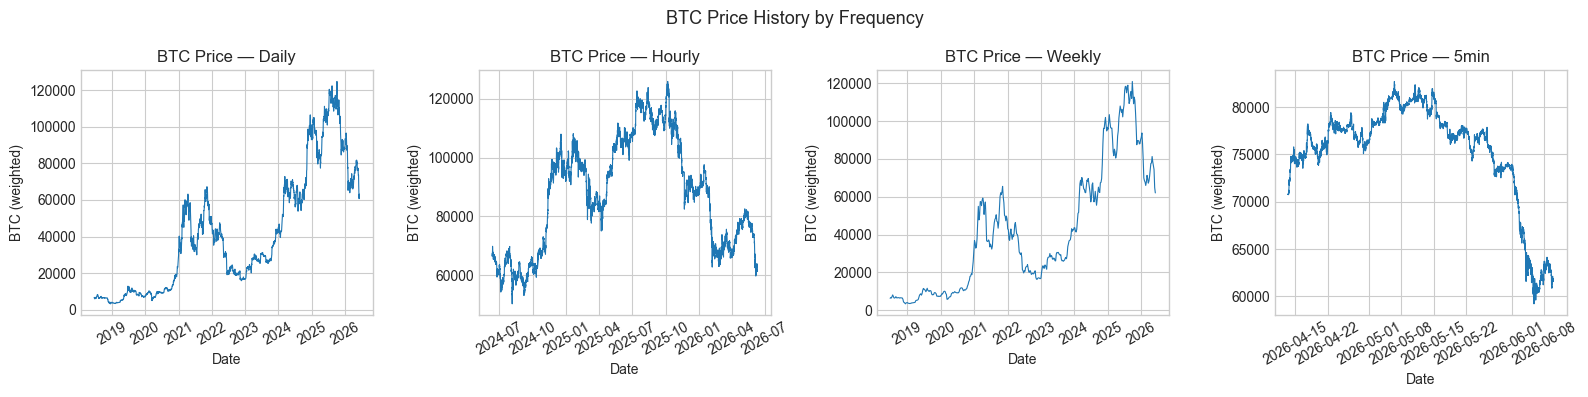

In [4]:
n_freq = len(datasets)
fig, axes = plt.subplots(1, n_freq, figsize=(max(14, 4 * n_freq), 4))
if n_freq == 1:
    axes = [axes]
for ax, (freq, df) in zip(axes, datasets.items()):
    ax.plot(df.index, df[TARGET], linewidth=0.8)
    ax.set_title(f'BTC Price — {freq}', fontsize=12)
    ax.set_xlabel('Date')
    ax.set_ylabel('BTC (weighted)')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('BTC Price History by Frequency', fontsize=13)
plt.tight_layout()
plt.show()

## 2. Utility Functions

In [5]:
# ---- Preprocessing helpers ----

def prepare_regression(df, target_col, test_size, top_n):
    """One-step-ahead: features at t → target at t+1."""
    y = df[target_col].shift(-1).dropna()
    X = df.iloc[:-1].copy()
    X_train = X.iloc[:-test_size]
    y_train = y.iloc[:-test_size]
    corrs   = X_train.corrwith(y_train).abs().sort_values(ascending=False)
    top_cols = corrs.head(top_n).index.tolist()

    X_top = X[top_cols]
    valid = X_top.dropna().index.intersection(y.index)
    return X_top.loc[valid], y.loc[valid], top_cols


def prepare_classification(df, target_col, test_size, top_n):
    """Binary target: 1 if price rose vs previous period, 0 otherwise."""
    y = (df[target_col].diff() > 0).astype(int).dropna()
    X = df.iloc[1:].copy()
    X_train = X.iloc[:-test_size]
    y_train = y.iloc[:-test_size]

    # Drop fully-NaN columns up front so SimpleImputer (keep_empty_features=False)
    # doesn't silently change the column count vs. X_train.columns.
    non_empty_cols = X_train.columns[X_train.notna().any()].tolist()
    X_train = X_train[non_empty_cols]

    pipe    = Pipeline([('imp', SimpleImputer()), ('sc', RobustScaler())])
    X_sc    = pipe.fit_transform(X_train)
    mi      = mutual_info_classif(X_sc, y_train, random_state=SEED)
    top_idx = np.argsort(mi)[::-1][:top_n]
    top_cols = X_train.columns[top_idx].tolist()

    X_top = X[top_cols]
    valid = X_top.dropna().index.intersection(y.index)
    return X_top.loc[valid], y.loc[valid], top_cols


def naive_persistence(y_train, y_test):
    pred = y_test.copy()
    pred.iloc[0] = y_train.iloc[-1]
    pred = pred.shift(1).ffill()
    return pred


def moving_average_baseline(y_train, y_test, window):
    combined = pd.concat([y_train.tail(window), y_test])
    return combined.rolling(window).mean().reindex(y_test.index).ffill()


print('Preprocessing helpers loaded.')

Preprocessing helpers loaded.


In [6]:
# ---- Visualization helpers ----

def plot_predictions_reg(y_test, preds_dict, freq):
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y_test.index, y_test.values, label='Actual', color='black', lw=2, zorder=5)
    colors = plt.cm.tab10(np.linspace(0, 1, len(preds_dict)))
    for (name, pred), color in zip(preds_dict.items(), colors):
        vals = pred.values if hasattr(pred, 'values') else pred
        ax.plot(y_test.index, vals, label=name, alpha=0.75, color=color)
    ax.set_title(f'Regression Predictions vs Actuals — {freq}', fontsize=13)
    ax.set_ylabel('BTC Price')
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_metrics_comparison(results_df, metric, freq):
    df = results_df.dropna(subset=[f'train_{metric}', f'test_{metric}'])
    x  = np.arange(len(df))
    w  = 0.35
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(x - w/2, df[f'train_{metric}'], w, label='Train', alpha=0.75)
    ax.bar(x + w/2, df[f'test_{metric}'],  w, label='Test',  alpha=0.75)
    ax.set_xticks(x)
    ax.set_xticklabels(df['Model'], rotation=30, ha='right')
    ax.set_ylabel(metric.upper())
    ax.set_title(f'{metric.upper()} by Model — {freq}')
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_roc_curves(y_true, proba_dict, freq):
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, proba in proba_dict.items():
        fpr, tpr, _ = roc_curve(y_true, proba)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})')
    ax.plot([0,1],[0,1],'k--', label='Random')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f'ROC Curves — {freq}')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(y_true, pred_dict, freq):
    n   = len(pred_dict)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1: axes = [axes]
    for ax, (name, pred) in zip(axes, pred_dict.items()):
        vals = pred.values if hasattr(pred, 'values') else pred
        ConfusionMatrixDisplay.from_predictions(
            y_true, vals, ax=ax,
            display_labels=['Down', 'Up'], colorbar=False, cmap='Blues'
        )
        ax.set_title(name, fontsize=10)
    fig.suptitle(f'Confusion Matrices — {freq}', fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_probability_timeline(y_true, proba_dict, freq):
    n    = len(proba_dict)
    fig, axes = plt.subplots(n, 1, figsize=(16, 3.5*n), sharex=True)
    if n == 1: axes = [axes]
    for ax, (name, proba) in zip(axes, proba_dict.items()):
        vals = proba.values if hasattr(proba, 'values') else proba
        idx  = proba.index  if hasattr(proba, 'index')  else y_true.index
        ax.fill_between(idx, vals, 0.5, where=vals>=0.5, alpha=0.35, color='green', label='P(Up)≥0.5')
        ax.fill_between(idx, vals, 0.5, where=vals <0.5, alpha=0.35, color='red',   label='P(Up)<0.5')
        ax.plot(idx, vals, color='navy', lw=0.9)
        ax.axhline(0.5, color='gray', ls='--', lw=1)
        ax2 = ax.twinx()
        ax2.plot(y_true.index, y_true.values, color='black', alpha=0.25, lw=1, label='Actual')
        ax2.set_ylabel('Actual (0/1)', fontsize=8)
        ax.set_ylabel('P(Up)')
        ax.set_title(f'{name} — {freq}')
        ax.legend(loc='upper left', fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_feature_importance(model, X, y, top_n, title):
    r   = permutation_importance(model, X, y, n_repeats=10, random_state=SEED, n_jobs=-1)
    imp = pd.Series(r.importances_mean, index=X.columns).sort_values().tail(top_n)
    fig, ax = plt.subplots(figsize=(9, 5))
    imp.plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'Permutation Importance — {title}')
    ax.set_xlabel('Mean importance')
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, freq, model_name):
    residuals = y_true - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].plot(y_true.index, residuals.values, lw=0.7, color='steelblue')
    axes[0].axhline(0, color='red', ls='--')
    axes[0].set_title('Residuals over time')
    axes[1].hist(residuals.values, bins=40, color='steelblue', edgecolor='white')
    axes[1].set_title('Residual distribution')
    from scipy import stats
    stats.probplot(residuals.values, dist='norm', plot=axes[2])
    axes[2].set_title('Q-Q plot')
    fig.suptitle(f'Residual Analysis — {model_name} / {freq}', fontsize=13)
    plt.tight_layout()
    plt.show()


print('Visualization helpers loaded.')

Visualization helpers loaded.


In [25]:
df = df.astype('float64')

## 3. Regression Models

In [ ]:
reg_results_all = {}
reg_preds_all   = {}

for freq, cfg in FREQ_CONFIGS.items():
    print(f"\n{'='*65}")
    print(f"  REGRESSION — {freq}")
    print('='*65)

    df        = datasets[freq]
    test_size = cfg['test_size']
    top_n     = cfg['top_features']
    ma_window = cfg['ma_window']

    X, y, top_cols = prepare_regression(df, TARGET, test_size, top_n)
    y_train = y.iloc[:-test_size]
    y_test  = y.iloc[-test_size:]
    X_test  = X.iloc[-test_size:]

    results, preds = [], {}

    # ── Naive (persistence) ──────────────────────────────────────
    naive_pred = naive_persistence(y_train, y_test)
    naive_tr   = naive_persistence(y_train.iloc[1:], y_train.iloc[:-1]).reindex(y_train.index).ffill()
    m_tr = compute_metrics(y_train.iloc[1:].values, naive_tr.iloc[1:].values, y_train.iloc[1:].values)
    m_te = compute_metrics(y_test.iloc[1:].values,  naive_pred.iloc[1:].values, y_train.iloc[1:].values)
    results.append({'Model': 'Naive', 'train_smape': m_tr['smape'], 'test_smape': m_te['smape'],
                    'train_mae': m_tr['mae'], 'test_mae': m_te['mae'],
                    'train_mase': m_tr['mase'], 'test_mase': m_te['mase']})
    preds['Naive'] = naive_pred

    # ── Moving Average ────────────────────────────────────────────
    ma_pred = moving_average_baseline(y_train, y_test, ma_window)
    m_te    = compute_metrics(y_test.values, ma_pred.values, y_train.values)
    results.append({'Model': f'MA-{ma_window}', 'train_smape': np.nan, 'test_smape': m_te['smape'],
                    'train_mae': np.nan, 'test_mae': m_te['mae'],
                    'train_mase': np.nan, 'test_mase': m_te['mase']})
    preds[f'MA-{ma_window}'] = ma_pred

    # ── Linear Models ─────────────────────────────────────────────
    for mtype in ['Ridge', 'Lasso', 'ElasticNet']:
        m = LinearForecaster(test_size=test_size, cv_splits=5, model_type=mtype,
                             n_trials=OPTUNA_TRIALS, seed=SEED, wandb_project=WANDB_PROJECT)
        m.fit(X, y)
        r = m.result_
        results.append({'Model': mtype,
                        'train_smape': r.metrics['train']['smape'], 'test_smape': r.metrics['test']['smape'],
                        'train_mae':   r.metrics['train']['mae'],   'test_mae':   r.metrics['test']['mae'],
                        'train_mase':  r.metrics['train']['mase'],  'test_mase':  r.metrics['test']['mase']})
        preds[mtype] = r.y_pred

    # ── Stacking Models ───────────────────────────────────────────
    for mtype in ['RandomForest', 'LightGBM', 'XGBoost', 'CatBoost']:
        m = StackingForecaster(model_type=mtype, test_size=test_size,
                               cv_splits=5, n_trials=OPTUNA_TRIALS, seed=SEED,
                               wandb_project=WANDB_PROJECT)
        m.fit(X, y)
        r = m.result_
        results.append({'Model': mtype,
                        'train_smape': r.metrics['train']['smape'], 'test_smape': r.metrics['test']['smape'],
                        'train_mae':   r.metrics['train']['mae'],   'test_mae':   r.metrics['test']['mae'],
                        'train_mase':  r.metrics['train']['mase'],  'test_mase':  r.metrics['test']['mase']})
        preds[mtype] = r.y_pred

    # ── ARIMA (skipped for 5min: too slow on 15k+ rows) ──────────
    if not cfg.get('skip_arima', False):
        arima = ARIMAForecaster(order=(1,1,1), test_size=test_size)
        arima.fit(df[[TARGET]], TARGET)
        r = arima.result_
        results.append({'Model': 'ARIMA(1,1,1)',
                        'train_smape': r.metrics['train']['smape'], 'test_smape': r.metrics['test']['smape'],
                        'train_mae':   r.metrics['train']['mae'],   'test_mae':   r.metrics['test']['mae'],
                        'train_mase':  r.metrics['train']['mase'],  'test_mase':  r.metrics['test']['mase']})
        preds['ARIMA'] = r.y_pred
    else:
        print(f"  ARIMA skipped (skip_arima=True for {freq})")

    res_df = pd.DataFrame(results).round(4)
    reg_results_all[freq] = res_df
    reg_preds_all[freq]   = {'preds': preds, 'y_test': y_test, 'X_test': X_test, 'y_train': y_train}

    display(
        res_df.sort_values('test_smape')
        .style.highlight_min(subset=['test_smape', 'test_mae', 'test_mase'], color='#c6efce')
              .highlight_max(subset=['test_smape', 'test_mae', 'test_mase'], color='#ffc7ce')
    )


  REGRESSION — Daily

[2026-06-10 23:07:50] Ridge начала обучаться

[2026-06-10 23:08:16] Ridge закончила обучаться

[2026-06-10 23:08:16] Lasso начала обучаться

[2026-06-10 23:08:18] Lasso закончила обучаться

[2026-06-10 23:08:18] ElasticNet начала обучаться

[2026-06-10 23:08:20] ElasticNet закончила обучаться

[2026-06-10 23:08:20] RandomForest начала обучаться

[2026-06-10 23:31:49] RandomForest закончила обучаться

[2026-06-10 23:31:49] LightGBM начала обучаться


/Users/tigran/python_projects_epta/учеба/диплом/ACTUAL_VERSION/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tigran/python_projects_epta/учеба/диплом/ACTUAL_VERSION/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tigran/python_projects_epta/учеба/диплом/ACTUAL_VERSION/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tigran/python_projects_epta/учеба/диплом/ACTUAL_VERSION/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/tigra


[2026-06-10 23:36:03] LightGBM закончила обучаться

[2026-06-10 23:36:04] XGBoost начала обучаться

[2026-06-10 23:39:21] XGBoost закончила обучаться

[2026-06-10 23:39:21] CatBoost начала обучаться


### 3.1 Regression — Prediction Plots (top models)

In [ ]:
for freq, cfg in FREQ_CONFIGS.items():
    d      = reg_preds_all[freq]
    y_test = d['y_test']
    res    = reg_results_all[freq].sort_values('test_smape')
    top5   = res.head(5)['Model'].tolist()
    top_p  = {m: d['preds'][m] for m in top5 if m in d['preds']}
    plot_predictions_reg(y_test, top_p, freq)

KeyError: 'Daily'

### 3.2 Regression — SMAPE & MASE Comparison

In [ ]:
for freq in FREQ_CONFIGS:
    plot_metrics_comparison(reg_results_all[freq], 'smape', freq)
    plot_metrics_comparison(reg_results_all[freq], 'mase',  freq)

### 3.3 Regression — Residual Analysis (best ML model per frequency)

In [ ]:
BASELINES = {'Naive', 'MA-7', 'MA-24', 'MA-4', 'MA-12'}

for freq in FREQ_CONFIGS:
    d      = reg_preds_all[freq]
    y_test = d['y_test']
    res    = reg_results_all[freq]

    ml_res = res[~res['Model'].isin(BASELINES)].sort_values('test_smape')
    if ml_res.empty:
        continue
    best   = ml_res.iloc[0]['Model']
    pred   = d['preds'].get(best)
    if pred is not None:
        pred_aligned = pred.reindex(y_test.index).ffill()
        plot_residuals(y_test, pred_aligned, freq, best)

### 3.4 Regression — Feature Importance (best ML model, daily)

In [ ]:
for freq in ['Daily']:
    d        = reg_preds_all[freq]
    y_test   = d['y_test']
    X_test   = d['X_test']
    res      = reg_results_all[freq]
    ml_res   = res[~res['Model'].isin(BASELINES | {'ARIMA(1,1,1)'})].sort_values('test_smape')
    if ml_res.empty:
        continue
    best_name = ml_res.iloc[0]['Model']
    # Retrain with best stacking model to get fitted object for permutation importance
    cfg       = FREQ_CONFIGS[freq]
    X_full, y_full, _ = prepare_regression(datasets[freq], TARGET, cfg['test_size'], cfg['top_features'])
    m = StackingForecaster(model_type=best_name if best_name in {'RandomForest','LightGBM','XGBoost','CatBoost'} else 'LightGBM',
                           test_size=cfg['test_size'], cv_splits=5, n_trials=10, seed=SEED)
    m.fit(X_full, y_full)
    plot_feature_importance(m.model_, X_test, y_test, top_n=15, title=f'{best_name} / {freq}')

## 4. Classification Models

### 4.0 Class Distribution

In [ ]:
n_freq = len(datasets)
fig, axes = plt.subplots(1, n_freq, figsize=(max(12, 4*n_freq + 2), 4))
if n_freq == 1:
    axes = [axes]
for ax, (freq, _) in zip(axes, FREQ_CONFIGS.items()):
    df    = datasets[freq]
    y_clf = (df[TARGET].diff() > 0).astype(int).dropna()
    vc    = y_clf.value_counts().sort_index()
    ax.bar(['Down (0)', 'Up (1)'], vc.values, color=['tomato', 'steelblue'], alpha=0.85, edgecolor='white')
    ax.set_title(f'{freq} — Class Balance\n({y_clf.mean()*100:.1f}% Up)', fontsize=11)
    ax.set_ylabel('Count')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 2, str(v), ha='center', fontsize=10)
plt.suptitle('Binary Target Distribution', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
clf_results_all = {}
clf_preds_all   = {}

for freq, cfg in FREQ_CONFIGS.items():
    print(f"\n{'='*65}")
    print(f"  CLASSIFICATION — {freq}")
    print('='*65)

    df        = datasets[freq]
    test_size = cfg['test_size']
    top_n     = cfg['top_features']

    X_clf, y_clf, top_cols = prepare_classification(df, TARGET, test_size, top_n)
    y_train = y_clf.iloc[:-test_size]
    y_test  = y_clf.iloc[-test_size:]
    X_test  = X_clf.iloc[-test_size:]

    results, preds, probas = [], {}, {}

    # ── Naive (majority class) ────────────────────────────────────
    majority    = int(y_train.mode()[0])
    naive_pred  = pd.Series(majority, index=y_test.index)
    naive_proba = pd.Series(float(majority), index=y_test.index)
    m = compute_clf_metrics(y_test.values, naive_pred.values, naive_proba.values)
    results.append({'Model': 'Naive (majority)', **m})
    preds['Naive']  = naive_pred
    probas['Naive'] = naive_proba

    # ── Logistic Regression ───────────────────────────────────────
    lr = LinearClassifier(test_size=test_size, cv_splits=5,
                          n_trials=OPTUNA_TRIALS, seed=SEED, wandb_project=WANDB_PROJECT)
    lr.fit(X_clf, y_clf)
    r  = lr.result_
    results.append({'Model': 'LogisticReg', **r.metrics['test']})
    preds['LogisticReg']  = r.y_pred
    probas['LogisticReg'] = r.y_proba

    # ── Stacking Classifiers ──────────────────────────────────────
    for mtype in ['RandomForest', 'LightGBM', 'XGBoost', 'CatBoost']:
        clf = StackingClassifierModel(model_type=mtype, test_size=test_size,
                                      cv_splits=5, n_trials=OPTUNA_TRIALS, seed=SEED,
                                      wandb_project=WANDB_PROJECT)
        clf.fit(X_clf, y_clf)
        r = clf.result_
        results.append({'Model': mtype, **r.metrics['test']})
        preds[mtype]  = r.y_pred
        probas[mtype] = r.y_proba

    res_df = pd.DataFrame(results).round(4)
    clf_results_all[freq] = res_df
    clf_preds_all[freq]   = {'preds': preds, 'probas': probas, 'y_test': y_test, 'X_test': X_test}

    display(
        res_df.sort_values('roc_auc', ascending=False)
        .style.highlight_max(subset=['accuracy','f1','roc_auc'], color='#c6efce')
              .highlight_min(subset=['accuracy','f1','roc_auc'], color='#ffc7ce')
    )

In [ ]:
clf_results_all = {}
clf_preds_all   = {}

for freq, cfg in FREQ_CONFIGS.items():
    print(f"\n{'='*65}")
    print(f"  CLASSIFICATION — {freq}")
    print('='*65)

    df        = datasets[freq]
    test_size = cfg['test_size']
    top_n     = cfg['top_features']

    X_clf, y_clf, top_cols = prepare_classification(df, TARGET, test_size, top_n)
    y_train = y_clf.iloc[:-test_size]
    y_test  = y_clf.iloc[-test_size:]
    X_test  = X_clf.iloc[-test_size:]

    results, preds, probas = [], {}, {}

    # ── Naive (majority class) ────────────────────────────────────
    majority    = int(y_train.mode()[0])
    naive_pred  = pd.Series(majority, index=y_test.index)
    naive_proba = pd.Series(float(majority), index=y_test.index)
    m = compute_clf_metrics(y_test.values, naive_pred.values, naive_proba.values)
    results.append({'Model': 'Naive (majority)', **m})
    preds['Naive']  = naive_pred
    probas['Naive'] = naive_proba

    # ── Logistic Regression ───────────────────────────────────────
    lr = LinearClassifier(test_size=test_size, cv_splits=5)
    lr.fit(X_clf, y_clf)
    r  = lr.result_
    results.append({'Model': 'LogisticReg', **r.metrics['test']})
    preds['LogisticReg']  = r.y_pred
    probas['LogisticReg'] = r.y_proba

    # ── Stacking Classifiers ──────────────────────────────────────
    for mtype in ['RandomForest', 'LightGBM', 'XGBoost', 'CatBoost']:
        clf = StackingClassifierModel(model_type=mtype, test_size=test_size,
                                      cv_splits=5, n_iter=10, seed=SEED)
        clf.fit(X_clf, y_clf)
        r = clf.result_
        results.append({'Model': mtype, **r.metrics['test']})
        preds[mtype]  = r.y_pred
        probas[mtype] = r.y_proba

    res_df = pd.DataFrame(results).round(4)
    clf_results_all[freq] = res_df
    clf_preds_all[freq]   = {'preds': preds, 'probas': probas, 'y_test': y_test, 'X_test': X_test}

    display(
        res_df.sort_values('roc_auc', ascending=False)
        .style.highlight_max(subset=['accuracy','f1','roc_auc'], color='#c6efce')
              .highlight_min(subset=['accuracy','f1','roc_auc'], color='#ffc7ce')
    )

### 4.2 ROC Curves

In [ ]:
for freq in FREQ_CONFIGS:
    d = clf_preds_all[freq]
    model_probas = {
        k: (v.values if hasattr(v, 'values') else v)
        for k, v in d['probas'].items()
        if k != 'Naive' and v.nunique() > 1
    }
    plot_roc_curves(d['y_test'].values, model_probas, freq)

### 4.3 Confusion Matrices

In [ ]:
for freq in FREQ_CONFIGS:
    d = clf_preds_all[freq]
    non_naive = {k: v for k, v in d['preds'].items() if k != 'Naive'}
    plot_confusion_matrices(d['y_test'].values, non_naive, freq)

### 4.4 Probability Timeline (top-2 models per frequency)

In [ ]:
for freq in FREQ_CONFIGS:
    d   = clf_preds_all[freq]
    res = clf_results_all[freq]
    top2 = (
        res[res['Model'] != 'Naive (majority)']
        .sort_values('roc_auc', ascending=False)
        .head(2)['Model'].tolist()
    )
    top2_probas = {m: d['probas'][m] for m in top2 if m in d['probas']}
    plot_probability_timeline(d['y_test'], top2_probas, freq)

### 4.5 Precision-Recall Curves

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

for freq in FREQ_CONFIGS:
    d   = clf_preds_all[freq]
    y_t = d['y_test'].values
    fig, ax = plt.subplots(figsize=(8, 6))
    for name, proba in d['probas'].items():
        if name == 'Naive': continue
        p_vals = proba.values if hasattr(proba, 'values') else proba
        if len(np.unique(p_vals)) <= 1: continue
        prec, rec, _ = precision_recall_curve(y_t, p_vals)
        ap = average_precision_score(y_t, p_vals)
        ax.plot(rec, prec, label=f'{name} (AP={ap:.3f})')
    baseline = y_t.mean()
    ax.axhline(baseline, color='gray', ls='--', label=f'Random (AP={baseline:.3f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curves — {freq}')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

### 4.6 Classification — Feature Importance

In [ ]:
from sklearn.metrics import make_scorer
from sklearn.metrics import roc_auc_score

for freq in ['Daily']:
    d   = clf_preds_all[freq]
    res = clf_results_all[freq]
    cfg = FREQ_CONFIGS[freq]

    ml_res = res[~res['Model'].isin({'Naive (majority)', 'LogisticReg'})].sort_values('roc_auc', ascending=False)
    if ml_res.empty:
        continue
    best_name = ml_res.iloc[0]['Model']

    df  = datasets[freq]
    X_clf, y_clf, _ = prepare_classification(df, TARGET, cfg['test_size'], cfg['top_features'])
    m   = StackingClassifierModel(model_type=best_name, test_size=cfg['test_size'],
                                   cv_splits=5, n_iter=5, seed=SEED)
    m.fit(X_clf, y_clf)
    X_te  = d['X_test']
    y_te  = d['y_test']
    plot_feature_importance(m.model_, X_te, y_te, top_n=15, title=f'{best_name} (CLF) / {freq}')

## 5. Summary: Best Models per Frequency

In [ ]:
print("\n" + "="*70)
print("  ИТОГОВОЕ СРАВНЕНИЕ")
print("="*70)

rows = []
for freq in FREQ_CONFIGS:
    best_reg = reg_results_all[freq].sort_values('test_smape').iloc[0]
    best_clf = clf_results_all[freq].sort_values('roc_auc', ascending=False).iloc[0]
    rows.append({
        'Frequency':         freq,
        'Best Regressor':    best_reg['Model'],
        'SMAPE (test)':      best_reg['test_smape'],
        'MASE (test)':       best_reg['test_mase'],
        'Best Classifier':   best_clf['Model'],
        'ROC-AUC':           best_clf['roc_auc'],
        'F1':                best_clf['f1'],
        'Accuracy':          best_clf['accuracy'],
    })

summary = pd.DataFrame(rows)
display(summary.style.set_properties(**{'text-align': 'center'}))

In [ ]:
# ── Visual summary: heatmap of test metrics across all classifiers ──

for freq in FREQ_CONFIGS:
    df_h = clf_results_all[freq].set_index('Model')[['accuracy', 'f1', 'precision', 'recall', 'roc_auc']]
    fig, ax = plt.subplots(figsize=(9, len(df_h)*0.6 + 1.5))
    sns.heatmap(df_h, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
                linewidths=0.5, vmin=0.4, vmax=1.0)
    ax.set_title(f'Classification Metrics Heatmap — {freq}', fontsize=13)
    plt.tight_layout()
    plt.show()